## **Library**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## **Load Dataset**

In [8]:
# Load Data
df = pd.read_csv('data/volve_production_data.csv')
df

# Exclude columns
exclude_columns = ['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'Faktor Pembagi', 'BORE_WI_VOL']
df = df.drop(columns=exclude_columns)
df.head()

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG Choke size,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,15/9-F-1 C,0.0,0.00000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,WI
1,2014-04-08,15/9-F-1 C,0.0,NaN,NaN,NaN,0.010031,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
2,2014-04-09,15/9-F-1 C,0.0,NaN,NaN,NaN,0.009790,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
3,2014-04-10,15/9-F-1 C,0.0,NaN,NaN,NaN,0.005458,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
4,2014-04-11,15/9-F-1 C,0.0,310.37614,96.87589,277.27826,0.012160,33.09788,10.47992,33.07195,0.0,0.0,0.0,production,OP


## **EDA**

In [9]:
df.isnull().sum()

DATEPRD                        0
NPD_WELL_BORE_NAME             0
ON_STREAM_HRS                285
AVG_DOWNHOLE_PRESSURE       6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_DP_TUBING               6654
AVG Choke size                 0
AVG_WHP_P                   6479
AVG_WHT_P                   6488
DP_CHOKE_SIZE                294
BORE_OIL_VOL                6473
BORE_GAS_VOL                6473
BORE_WAT_VOL                6473
FLOW_KIND                      0
WELL_TYPE                      0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DATEPRD                   15634 non-null  object 
 1   NPD_WELL_BORE_NAME        15634 non-null  object 
 2   ON_STREAM_HRS             15349 non-null  float64
 3   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64
 4   AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64
 5   AVG_DP_TUBING             8980 non-null   float64
 6   AVG Choke size            15634 non-null  float64
 7   AVG_WHP_P                 9155 non-null   float64
 8   AVG_WHT_P                 9146 non-null   float64
 9   DP_CHOKE_SIZE             15340 non-null  float64
 10  BORE_OIL_VOL              9161 non-null   float64
 11  BORE_GAS_VOL              9161 non-null   float64
 12  BORE_WAT_VOL              9161 non-null   float64
 13  FLOW_KIND                 15634 non-null  object 
 14  WELL_T

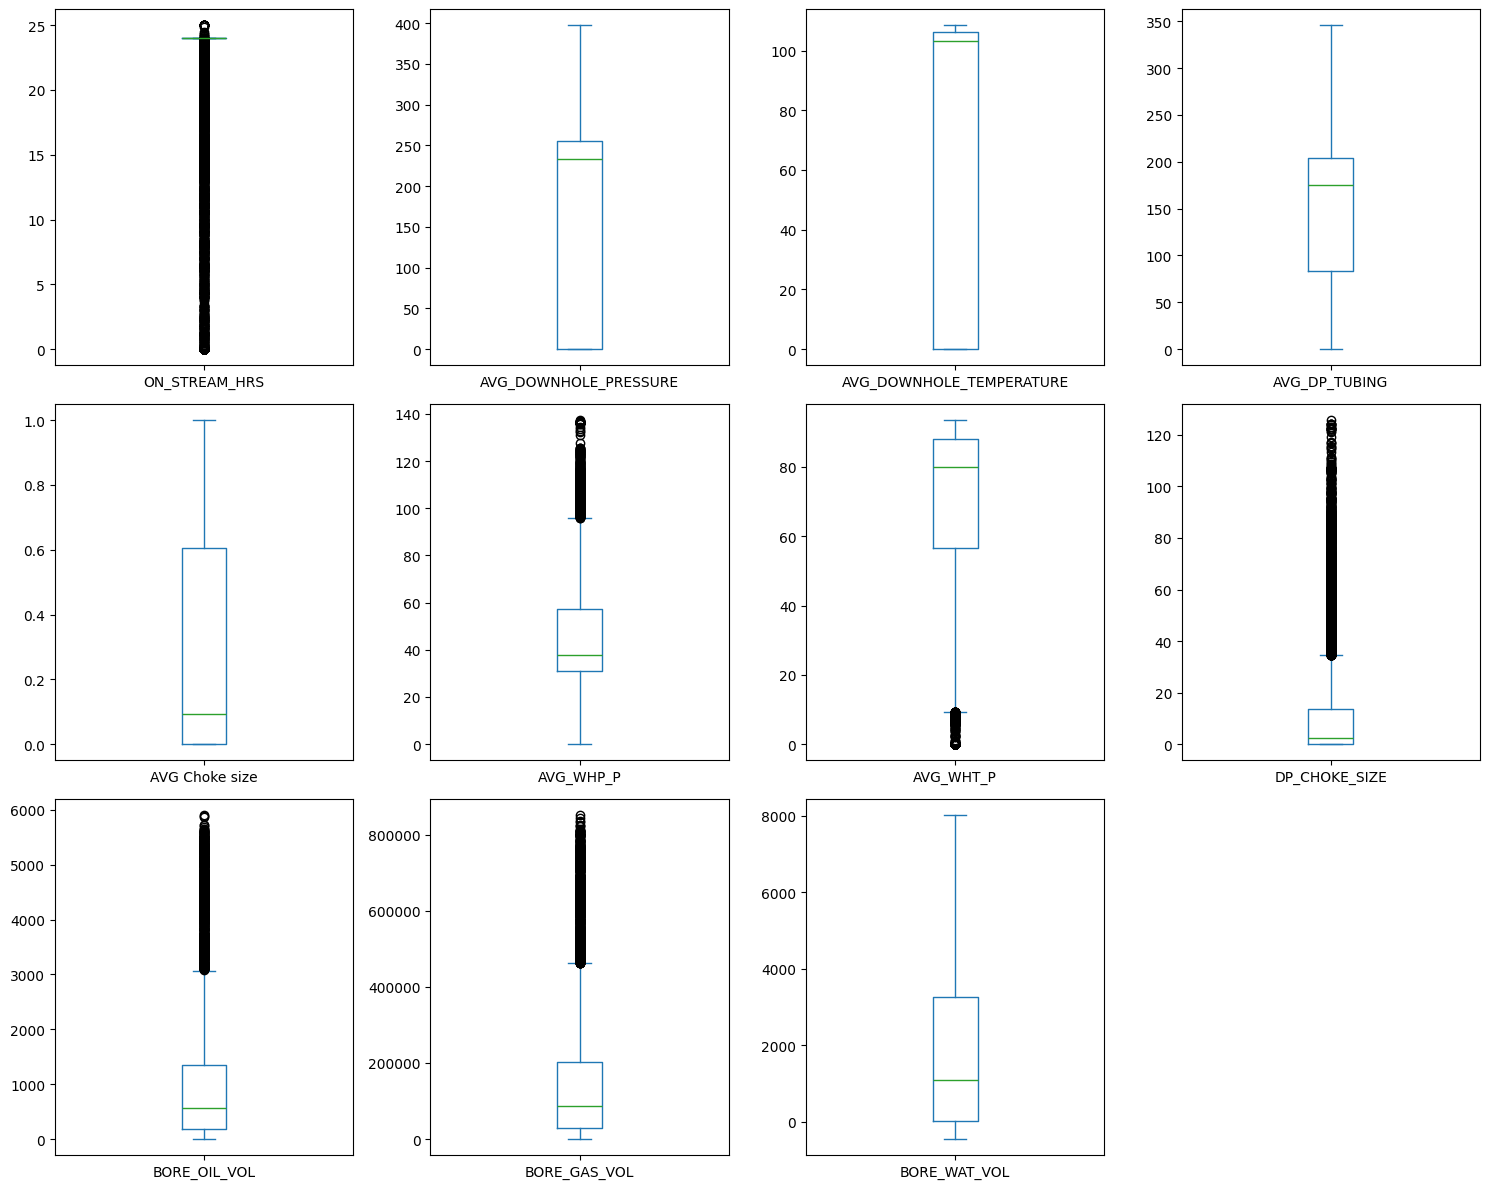

In [ ]:
df_numerik = df.select_dtypes(include=['float64'])

jumlah_kolom = len(df_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(15, 4 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

## **Preprocessing**

In [16]:
print(len(df))

15634


In [26]:
df['WELL_TYPE'].unique()

array(['OP'], dtype=object)

In [25]:
# Drop row kondisi tertentu

# BORE_OIL_VOL > 0
df = df[df['BORE_OIL_VOL'] > 0]

# FLOW_KIND = 'production'
df = df[df['FLOW_KIND'] == 'production']

# WELL_TYPE = 'OP'
df = df[df['WELL_TYPE'] == 'OP']

In [27]:
print(len(df))

7999


In [29]:
# Standarasasi Format Date
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'], format='%Y-%m-%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7999 entries, 15 to 15610
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   7999 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        7999 non-null   object        
 2   ON_STREAM_HRS             7999 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     7863 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  7863 non-null   float64       
 5   AVG_DP_TUBING             7863 non-null   float64       
 6   AVG Choke size            7999 non-null   float64       
 7   AVG_WHP_P                 7996 non-null   float64       
 8   AVG_WHT_P                 7996 non-null   float64       
 9   DP_CHOKE_SIZE             7996 non-null   float64       
 10  BORE_OIL_VOL              7999 non-null   float64       
 11  BORE_GAS_VOL              7999 non-null   float64       
 12  BORE_WAT_VOL           

In [30]:
df.isnull().sum()

DATEPRD                       0
NPD_WELL_BORE_NAME            0
ON_STREAM_HRS                 0
AVG_DOWNHOLE_PRESSURE       136
AVG_DOWNHOLE_TEMPERATURE    136
AVG_DP_TUBING               136
AVG Choke size                0
AVG_WHP_P                     3
AVG_WHT_P                     3
DP_CHOKE_SIZE                 3
BORE_OIL_VOL                  0
BORE_GAS_VOL                  0
BORE_WAT_VOL                  0
FLOW_KIND                     0
WELL_TYPE                     0
dtype: int64

## **Feature Engineering**

In [32]:
# Penambahan kolom baru untuk analisis lebih lanjut

# Water Cut
df['WAT_CUT'] = df['BORE_WAT_VOL'] / (df['BORE_OIL_VOL'] + df['BORE_WAT_VOL'])

# Oil Cut
df['OIL_CUT'] = df['BORE_OIL_VOL'] / (df['BORE_OIL_VOL'] + df['BORE_WAT_VOL'])

## **Feature Selection**

In [33]:
# Variabel yang akan digunakan untuk analisis lebih lanjut

var = ['DP_CHOKE_SIZE', 'ON_STREAM_HRS', 'AVG_DP_TUBING', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_WHP_P', 'AVG_WHT_P', 'BORE_OIL_VOL', 'BORE_WAT_VOL']

X = df[var]
y = df['AVG Choke size']

In [35]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [37]:
# Standarisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Modelling**

In [ ]:
model = 